<a href="https://colab.research.google.com/github/karamdh/arene-des-algos-KARAM-DHIFI01/blob/main/jour2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Forme :", df.shape)
print("\nTypes des colonnes :")
print(df.dtypes)
print("\nAperçu des 5 premières lignes :")
df.head()

Forme : (7043, 21)

Types des colonnes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Aperçu des 5 premières lignes :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# phase 1
def audit_qualite(df):
    """Rapport de santé du dataset."""


    print("=" * 45)
    print(f"FORME : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print("=" * 45)


    print("\nTYPES DES COLONNES :")
    print(df.dtypes)


    print("\nVALEURS MANQUANTES (%) :")
    manquants = df.isnull().mean().sort_values(ascending=False) * 100
    manquants_affiches = manquants[manquants > 0]
    if manquants_affiches.empty:
        print("  → 0 colonne avec des NaN détectés (attention aux trous cachés !)")
    else:
        print(manquants_affiches.round(2))


    print("\nRÉPARTITION DE LA CIBLE (Churn) :")
    if "Churn" not in df.columns:
        print("   Colonne 'Churn' introuvable !")
        return
    compte = df["Churn"].value_counts()
    pct = df["Churn"].value_counts(normalize=True) * 100
    for val in compte.index:
        print(f"  {val} : {compte[val]} ({pct[val]:.1f}%)")
    print("=" * 45)


audit_qualite(df)

FORME : 7043 lignes × 21 colonnes

TYPES DES COLONNES :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

VALEURS MANQUANTES (%) :
  → 0 colonne avec des NaN détectés (attention aux trous cachés !)

RÉPARTITION DE LA CIBLE (Churn) :
  No : 5174 (73.5%)
  Yes : 1869 (26.5%)


In [6]:

df_une_classe = df[df["Churn"] == "No"]
print("--- CAS LIMITE (une seule classe) ---")
audit_qualite(df_une_classe)

df_sans_cible = df.drop(columns=["Churn"])
print("--- CAS ADVERSARIAL (sans colonne Churn) ---")
audit_qualite(df_sans_cible)

--- CAS LIMITE (une seule classe) ---
FORME : 5174 lignes × 21 colonnes

TYPES DES COLONNES :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

VALEURS MANQUANTES (%) :
  → 0 colonne avec des NaN détectés (attention aux trous cachés !)

RÉPARTITION DE LA CIBLE (Churn) :
  No : 5174 (100.0%)
--- CAS ADVERSARIAL (sans colonne Churn) ---
FORME : 7043 lignes × 20 colonnes

TYPES DES COLONNES :
customerID           object
gender               objec

In [7]:
def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés."""

    df = df.copy()
    colonne = "TotalCharges"


    test_conversion = pd.to_numeric(df[colonne], errors="coerce")
    taux_nan = test_conversion.isna().mean()
    if taux_nan == 1.0:
        print(f" REFUS : '{colonne}' est 100% non numérique. Conversion annulée.")
        return df

    avant = df[colonne].isna().sum()
    df[colonne] = pd.to_numeric(df[colonne], errors="coerce")
    apres = df[colonne].isna().sum()
    trous_debusques = apres - avant

    print(f"Trous démasqués dans '{colonne}' : {trous_debusques}")
    print(f"Type après conversion : {df[colonne].dtype}")


    mediane = df[colonne].median()
    df[colonne] = df[colonne].fillna(mediane)
    print(f"Imputation par médiane : {mediane:.2f}")
    print(f"NaN restants : {df[colonne].isna().sum()}")

    return df


df = reparer_total_charges(df)

print("\n--- TEST ADVERSARIAL : virgules dans MonthlyCharges ---")
df_corrompu = df.copy()
df_corrompu.loc[0, "MonthlyCharges"] = "29,90"

def detecter_virgules(df, colonne):
    """Détecte les valeurs avec virgule décimale avant conversion."""
    masque = df[colonne].astype(str).str.contains(r"\d,\d", regex=True)
    nb = masque.sum()
    if nb > 0:
        print(f" {nb} valeur(s) avec virgule détectée(s) dans '{colonne}' :")
        print(df.loc[masque, colonne].head())
    else:
        print(f" Aucune virgule suspecte dans '{colonne}'")

detecter_virgules(df_corrompu, "MonthlyCharges")

Trous démasqués dans 'TotalCharges' : 11
Type après conversion : float64
Imputation par médiane : 1397.47
NaN restants : 0

--- TEST ADVERSARIAL : virgules dans MonthlyCharges ---
 1 valeur(s) avec virgule détectée(s) dans 'MonthlyCharges' :
0    29,90
Name: MonthlyCharges, dtype: object


/tmp/ipykernel_7235/3929372532.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29,90' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_corrompu.loc[0, "MonthlyCharges"] = "29,90"


In [8]:
def encoder_features(df):
    """Encode toutes les colonnes catégorielles."""

    df = df.copy()

    df = df.drop(columns=["customerID"])

    binaires_yes_no = [col for col in df.select_dtypes("object").columns
                       if set(df[col].dropna().unique()).issubset({"Yes", "No"})]

    for col in binaires_yes_no:
        df[col] = df[col].map({"Yes": 1, "No": 0})

    df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

    contrat_ordre = {"Month-to-month": 0, "One year": 1, "Two year": 2}
    df["Contract"] = df["Contract"].map(contrat_ordre)

    nominales = df.select_dtypes("object").columns.tolist()
    df = pd.get_dummies(df, columns=nominales, drop_first=False)


    bool_cols = df.select_dtypes("bool").columns
    df[bool_cols] = df[bool_cols].astype(int)

    rapport = pd.DataFrame({
        "Métrique": [
            "Colonnes avant encodage",
            "Colonnes après encodage",
            "Colonnes binaires Yes/No encodées",
            "Colonnes ordinales encodées",
            "Colonnes One-Hot encodées",
            "Types restants object",
            "customerID supprimé"
        ],
        "Valeur": [
            "21",
            str(df.shape[1]),
            str(len(binaires_yes_no)),
            "Contract",
            str(len(nominales)),
            str(df.select_dtypes("object").shape[1]),
            " Oui"
        ]
    })

    print("\n Rapport d'encodage — Phase 3")
    print(rapport.to_string(index=False))

    return df

df = encoder_features(df)
print(f"\nAperçu des colonnes finales ({df.shape[1]}) :")
print(df.dtypes.to_string())


 Rapport d'encodage — Phase 3
                         Métrique   Valeur
          Colonnes avant encodage       21
          Colonnes après encodage       39
Colonnes binaires Yes/No encodées        5
      Colonnes ordinales encodées Contract
        Colonnes One-Hot encodées        9
            Types restants object        0
              customerID supprimé      Oui

Aperçu des colonnes finales (39) :
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
MultipleLines_No            


 Rapport outliers — Phase 4
       Colonne  Borne basse  Borne haute  Nb outliers  Churn perdus si suppression
        tenure       -60.00       124.00            0                            0
MonthlyCharges       -46.02       171.38            0                            0
  TotalCharges     -4674.34      8863.16            0                            0


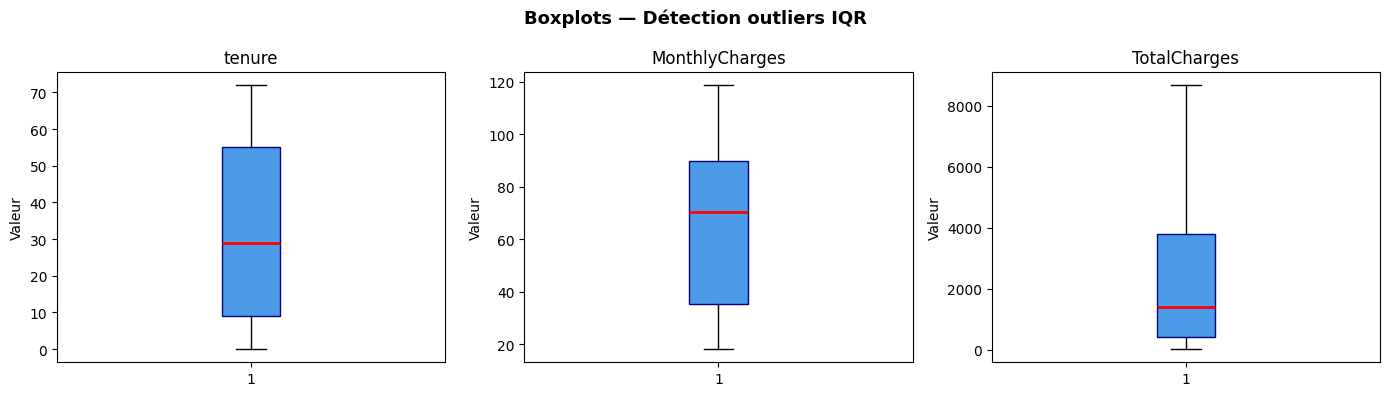

In [10]:
import matplotlib.pyplot as plt

def detecter_outliers_iqr(df, colonne):
    """Renvoie les bornes IQR et le nombre d'outliers d'une colonne numérique."""

    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    outliers = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)]
    nombre_outliers = len(outliers)

    return borne_basse, borne_haute, nombre_outliers



colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]

lignes = []
for col in colonnes_num:
    bb, bh, n = detecter_outliers_iqr(df, col)
    # Outliers qui sont aussi Churn=1
    outliers_mask = (df[col] < bb) | (df[col] > bh)
    churn_perdus = df[outliers_mask]["Churn"].sum() if n > 0 else 0
    lignes.append({
        "Colonne": col,
        "Borne basse": round(bb, 2),
        "Borne haute": round(bh, 2),
        "Nb outliers": n,
        "Churn perdus si suppression": churn_perdus
    })

rapport_outliers = pd.DataFrame(lignes)
print("\n Rapport outliers — Phase 4")
print(rapport_outliers.to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(colonnes_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#4C9BE8", color="navy"),
                    medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel("Valeur")

plt.suptitle("Boxplots — Détection outliers IQR", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

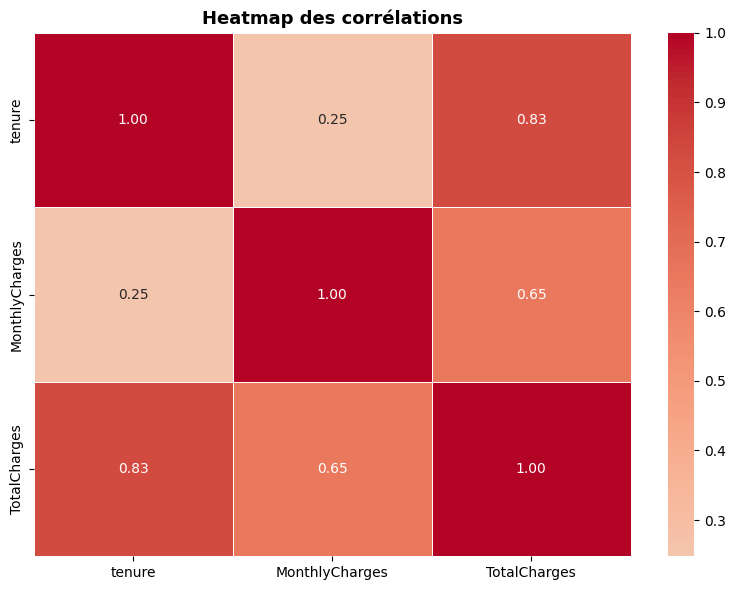


 Rapport VIF — Phase 5
       Colonne  VIF        Statut
        tenure 6.32  à surveiller
MonthlyCharges 3.36              
  TotalCharges 8.07  à surveiller

--- EDGE CASE : colonne dupliquée ---


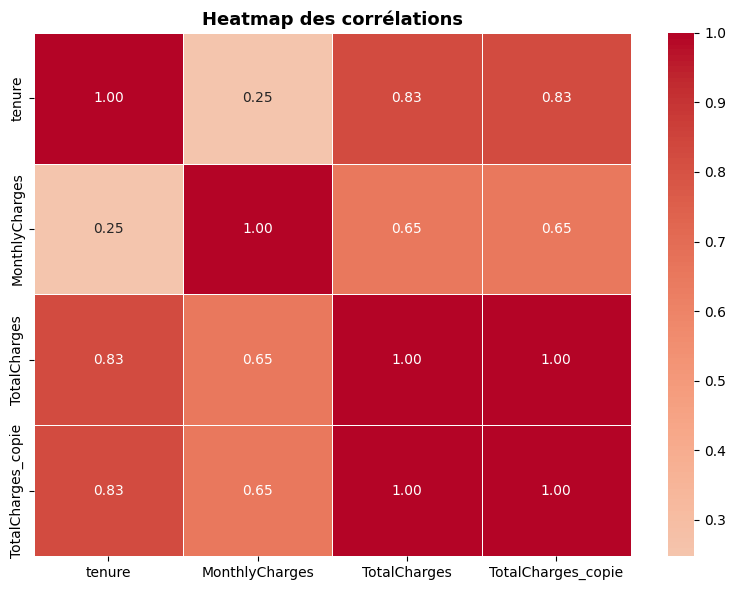

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



 Rapport VIF — Phase 5
           Colonne                     VIF        Statut
            tenure                    6.32  à surveiller
    MonthlyCharges                    3.36              
      TotalCharges ∞ (colonne dupliquée !)              
TotalCharges_copie ∞ (colonne dupliquée !)              

--- APRÈS suppression TotalCharges ---


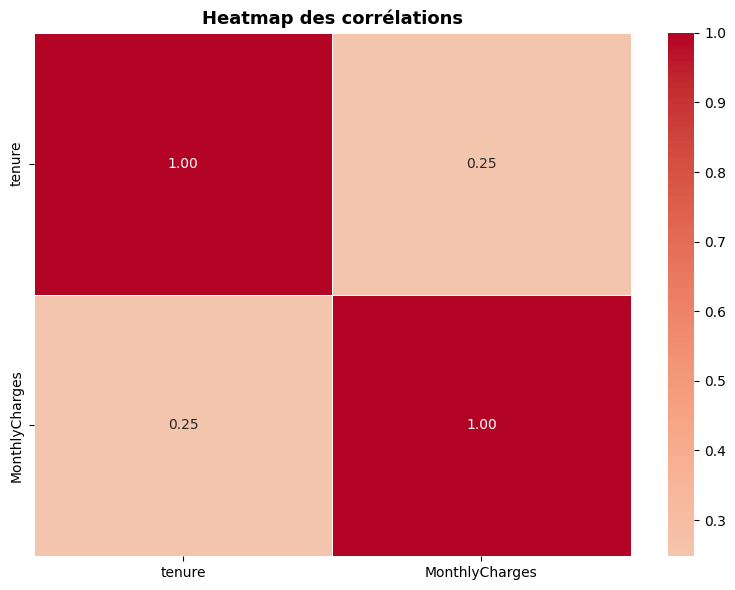


 Rapport VIF — Phase 5
       Colonne  VIF Statut
        tenure 2.61       
MonthlyCharges 2.61       


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

def rapport_multicolinearite(df, colonnes_num):
    """Heatmap des corrélations et VIF des colonnes numériques."""

    data = df[colonnes_num].dropna()

    corr = data.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5)
    plt.title("Heatmap des corrélations", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    lignes_vif = []
    for i, col in enumerate(colonnes_num):
        try:
            vif = variance_inflation_factor(data.values, i)
            if np.isinf(vif) or np.isnan(vif):
                vif_affiche = "∞ (colonne dupliquée !)"
                alerte = ""
            elif vif > 10:
                vif_affiche = f"{vif:.2f}"
                alerte = " multicolinéarité sévère"
            elif vif > 5:
                vif_affiche = f"{vif:.2f}"
                alerte = " à surveiller"
            else:
                vif_affiche = f"{vif:.2f}"
                alerte = ""
        except Exception:
            vif_affiche = "Erreur"
            alerte = ""
        lignes_vif.append({"Colonne": col, "VIF": vif_affiche, "Statut": alerte})

    rapport = pd.DataFrame(lignes_vif)
    print("\n Rapport VIF — Phase 5")
    print(rapport.to_string(index=False))



colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]
rapport_multicolinearite(df, colonnes_num)


print("\n--- EDGE CASE : colonne dupliquée ---")
df_test = df[colonnes_num].copy()
df_test["TotalCharges_copie"] = df_test["TotalCharges"]
rapport_multicolinearite(df_test, colonnes_num + ["TotalCharges_copie"])


print("\n--- APRÈS suppression TotalCharges ---")
rapport_multicolinearite(df, ["tenure", "MonthlyCharges"])